### 부스팅(boost)
- 모델을 순차적으로 학습 
- 이전 모델이 잘못 맞추거나 확률이 애매한 경우 데이터에 가중치를 증가 -> 다음 모델에서 집중 학습
- 단순 모델들을 결합하여 강력 모델로 생성 
- 장점
    - 편향 감소 -> 예측의 확률이 올라간다
    - 단순한 모델들을 이어서 학습하기때문에 성능이 많이 올라간다. 
- 단점 
    - 순차적으로 학습 -> 병렬화 어려움 -> 학습 속도가 느려짐
    - 학습의 횟수가 너무 많은 경우 -> 과적합 위험
    - 파라미터 튜닝이 중요
- 대표 알고리즘
    - AdaBoost
        - 오차가 큰 샘플에 더 높은 가중치를 부여 
        - 각각의 모델들이 가중치가 조정이 된 데이터셋을 이용하여 학습 
        - 최종 모델에서는 가중치의 합산으로 결정 
    - Gradient Boosting(GBM)
        - 이전 모델의 잔차를 예측하는 새로운 모델을 추가 
        - 손실 함수를 직접 최적화 
        - 계산량이 많음
    - XGBoost
        - GBM을 개선한 알고리즘 
        - 규제, 병렬 학습 지원 ->병렬 지원을 통해서 시간 감소, 규제를 통해서 과적합 방지 
        - 대표적인 부스팅 알고리즘
        - 해당 모델은 라이브러리 추가적인 설치
    - LightGBM
        - XGBoost에 비해 속도면에서 우수 
        - 히스토그램 기반 학습을 통해서 대용량 데이터의 처리에 특화
    - CatBoost
        - 범주형 데이터들을 자동 처리 
        - 비교적인 튜닝이 간단

#### AdaBoost(분류)
- 초기에는 모든 샘플의 가중치를 동일하게 부여 
- 첫번째 모델에서는 약한 모델을 학습  -> 잘못 분류한 샘플에 대해서 가중치를 증가 
- 가중치가 증가한 데이터를 이용하여 다음 모델에서 학습하여 더 잘 맟추도록 집중 학습 
- parameter
    - estimator (base_estimator 매개변수는 sklearn의 구버전에서 사용)
        - 기본값 : DecisionTreeClassfier(max_depth = 1)
        - 모델 리스트
            - DecisionTreeClassfier : 매개변수의 값들을 바꿔서 사용 가능 -> 의사결정나무
            - LogisticRegression : 선형 분류 모델
            - SVC(probability = True) : 확률 예측을 True로 변경해야지만 사용이 가능
    - n_estimator
        - 기본값 : 50
        - 일반적으로 50~ 500
        - 모델의 개수
            - 개수가 너무 많아지면 시간이 증가, 과적합 위험성 증가
    - learning_rate
        - 기본값 : 1.0
        - 각 단계별 기여도(가중치)
        - 일반적으로 0.1 ~ 1.0
        - n_estimator와 상호 보안적으로 설정 (rate을 작게하면 모델의 개수를 증가)
        - 약한 모델의 기여도를 조절하는 스케일링 값
        - 값이 작은 경우  -> 각 단계별 영향이 줄어듬 -> 많은 모델이 필요
        - 데이터의 크기 / 복잡도가 클수록 모델의 개수를 늘리고 기여도를 줄여주는것이 유리 
        - 작은 데이터인 경우 데이터의 개수를 줄이고 기여도를 증가시키는게 유리
    - algorithm
        - 기본값 : SAMME.R
        - SAMME.R : 확률을 사용. 보통 시간이 빠르고 성능이 우수
        - SAMME : 클래스별 점수를 기반(확률이 필요 없음)
- 속성 
    - estimators_
        - 학습된 모델들의 리스트 
    - estimators_weights_
        - 각 모델들의 가중치(분류 중요)
    - estimators_errors_
        - 각 단계별 오차율
    - feature_inforranses_
        - feature별 중요도 (가중치의 합)
- 메서드 
    - staged_predict(X) / staged_predict_proba(X)
        - 각 단계별 누적 모델의 예측을 순차적으로 제공 (학습 곡선)

In [2]:
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report
import pandas as pd

In [3]:
body = pd.read_csv("../data/bodyPerformance.csv")
body.head(3)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C


In [4]:
# gender컬럼의 M ->0, F -> 1
body['gender'] = body['gender'].map(
    lambda x : 0 if x == 'M' else 1
)

In [5]:
# class 값 1,2,3,4 형태로 변환 
body['class'] = body['class'].map(
    {
        'A' : 1, 
        'B' : 2, 
        'C' : 3, 
        'D' : 4
    }
)

In [6]:
body.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  int64  
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  int64  
dtypes: float64(10), int64(2)
memory usage: 1.2 MB


In [7]:
x = body.drop('class', axis=1)
y = body['class']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [9]:
clf = AdaBoostClassifier()
clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [10]:
pred = clf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       0.59      0.61      0.60       685
           2       0.41      0.49      0.45       662
           3       0.51      0.45      0.48       650
           4       0.78      0.70      0.73       682

    accuracy                           0.56      2679
   macro avg       0.57      0.56      0.57      2679
weighted avg       0.57      0.56      0.57      2679



In [11]:
# AdaBoost에서 하이퍼파라미터(매개변수) 수정 
# 모델의 개수를 증가시키면야 기여도를 줄여준다. 
clf2 = AdaBoostClassifier(
    n_estimators=500, learning_rate=0.1
)

In [12]:
clf2.fit(X_train, y_train)

pred2 = clf2.predict(X_test)

print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           1       0.51      0.68      0.58       685
           2       0.40      0.37      0.39       662
           3       0.48      0.45      0.46       650
           4       0.81      0.65      0.72       682

    accuracy                           0.54      2679
   macro avg       0.55      0.54      0.54      2679
weighted avg       0.55      0.54      0.54      2679



In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
clf3 = AdaBoostClassifier(
    estimator= DecisionTreeClassifier(max_depth=4), 
    n_estimators=500, learning_rate=0.1
)

In [15]:
clf3.fit(X_train, y_train)

pred3 = clf3.predict(X_test)

print(classification_report(y_test, pred3))

              precision    recall  f1-score   support

           1       0.75      0.78      0.76       685
           2       0.53      0.63      0.58       662
           3       0.66      0.62      0.64       650
           4       0.92      0.77      0.84       682

    accuracy                           0.70      2679
   macro avg       0.72      0.70      0.71      2679
weighted avg       0.72      0.70      0.71      2679



In [16]:
# AdaBoost 에서 컬럼별 중요도가 어떤 컬럼이 가장 높은가?
importances = clf3.feature_importances_
importances

array([0.12470385, 0.02325894, 0.01757307, 0.05239439, 0.04655286,
       0.00341321, 0.00138066, 0.04373685, 0.46171545, 0.19803323,
       0.02723749])

In [17]:
x.columns

Index(['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic',
       'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts',
       'broad jump_cm'],
      dtype='object')

In [19]:
feature_df = pd.DataFrame(zip( x.columns, importances ), columns = ['feature_name', 'importance'])

In [21]:
# importance에 따라 내림차순 정렬 
feature_df.sort_values('importance', ascending = False).head()

,feature_name,importance
8,sit and bend forward_cm,0.461715
9,sit-ups counts,0.198033
0,age,0.124704
3,weight_kg,0.052394
4,body fat_%,0.046553


#### AdaBoost(회귀)
- 여러 개의 약한 회귀 모델을 순차적으로 학습하여 이전 단계의 오차를 줄이도록 가중치를 조절하여 높은 성능의 회귀 모델을 생성 
- parameter
    - estimator
        - 기본값 : DecisionTreeRegresiion(max_depth = 3)
        - DecisionTreeRegression : 매개변수들을 변경하여 사용 가능 
        - LinearRegression : 선형 회귀 모델 
        - Ridge : 릿지 모델(L2 패널티)
        - SVR : 서포트벡터 머신 (max_iter 값 조절)
    - loss
        - 기본값 : linear
        - 오차에 대한 가중치의 변환 방식 
        - linear : 기본적인 선형 업데이트 
        - square : 제곱, 큰 오타에 더 민감 
        - exponential : 지수, 매우 큰 오차를 더 강하게 패널티 

In [22]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [23]:
car = pd.read_csv("../data/CarPrice_Assignment.csv")

In [24]:
df = car.select_dtypes('number')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   wheelbase         205 non-null    float64
 3   carlength         205 non-null    float64
 4   carwidth          205 non-null    float64
 5   carheight         205 non-null    float64
 6   curbweight        205 non-null    int64  
 7   enginesize        205 non-null    int64  
 8   boreratio         205 non-null    float64
 9   stroke            205 non-null    float64
 10  compressionratio  205 non-null    float64
 11  horsepower        205 non-null    int64  
 12  peakrpm           205 non-null    int64  
 13  citympg           205 non-null    int64  
 14  highwaympg        205 non-null    int64  
 15  price             205 non-null    float64
dtypes: float64(8), int64(8)
memory usage: 25.8 K

In [27]:
df.drop('car_ID', axis=1, inplace=True)

In [28]:
x = df.drop('price', axis=1)
y = df['price']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [30]:
reg = AdaBoostRegressor()

In [31]:
reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [32]:
pred = reg.predict(X_test)

In [34]:
print( "MAE : ", round( mean_absolute_error(y_test, pred), 2 ))
print( "R2 : ", round( r2_score(y_test, pred), 2 ) )

MAE :  1966.13
R2 :  0.91


In [35]:
reg2 = AdaBoostRegressor(n_estimators=500, learning_rate=0.1)

In [36]:
reg2.fit(X_train, y_train)
pred2 = reg2.predict(X_test)

print("MAE : ", round( mean_absolute_error(y_test, pred2), 2 ))
print('R2 : ', round( r2_score(y_test, pred2), 2 ))

MAE :  1980.38
R2 :  0.9


In [37]:
import matplotlib.pyplot as plt

In [ ]:
list(reg2.staged_predict(X_test))

In [40]:
# 각 단계별 예측값을 이용하여 MAE를 구하고 그래프로 시각화 
mae_list = []

for stage_pred in list(reg2.staged_predict(X_test)):
    # stage_pred : 각 단계별 예측값(1차원 데이터)
    mae = mean_absolute_error(y_test, stage_pred)
    mae_list.append(mae)

mae_list

[2438.2935021601384,
 2709.3027565029097,
 2254.9787110037387,
 2403.6075240751543,
 2037.9984716841197,
 2033.292920211331,
 2091.591750143786,
 2191.589110818136,
 2083.0589113881815,
 2137.8919558185107,
 2123.660604658352,
 2121.0647617426916,
 2088.934215501596,
 2198.751420407614,
 2099.7811476155466,
 2118.6884019268455,
 2029.3260912610606,
 2073.5528811252316,
 2078.9770278555393,
 2110.65030791982,
 2106.597740208413,
 2088.055220105541,
 2051.7915445107337,
 2065.6272713048475,
 2069.312948925389,
 2071.8455102473204,
 2040.4266873201757,
 2062.8155450374506,
 2059.908912839711,
 2091.66109192307,
 2070.846536804555,
 2051.2862851215973,
 2043.5230560694195,
 2040.4921354216024,
 2051.594985917165,
 2034.974413988982,
 2040.263612568329,
 2019.8731414779681,
 2043.6553775503928,
 2044.8743815560922,
 2031.4731158415952,
 2007.9838556674815,
 2015.0433181636886,
 2005.6072675479063,
 2055.535663991662,
 2016.967523072194,
 2000.976854993782,
 1975.094816691128,
 1965.35288339

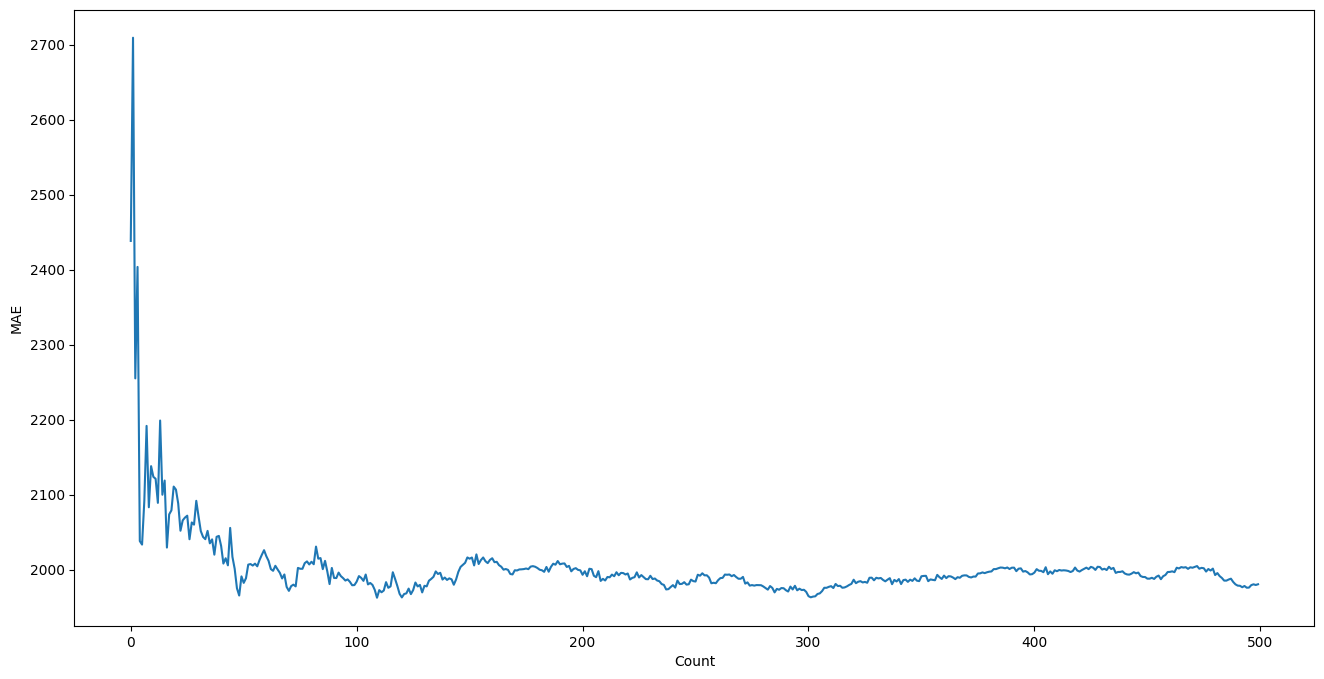

In [41]:
# 평균 절대 오차 변화를 그래프로 시각화
plt.figure(figsize = (16, 8))

plt.plot(mae_list)

plt.xlabel('Count')
plt.ylabel('MAE')

plt.show()

In [46]:
importance = reg2.feature_importances_
cols = x.columns

importance_df = pd.DataFrame(
    zip(cols, importance), 
    columns = [ 'feature_name', 'importance' ]
)
importance_df.sort_values('importance', ascending=True, inplace=True)

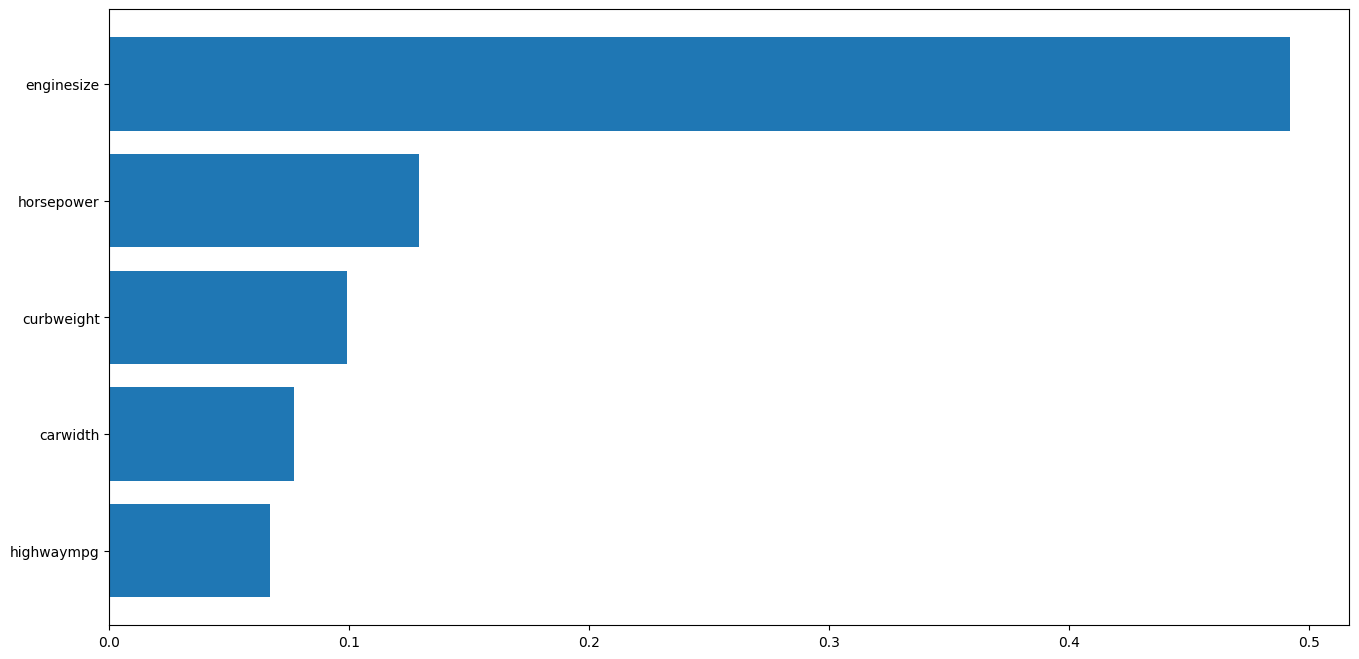

In [47]:
plt.figure(figsize = (16, 8))

plt.barh( importance_df['feature_name'].tail(), importance_df['importance'].tail() )

plt.show()